In [87]:
#PANDAS
import pandas as pd

#NUMPY
import numpy as np

#MATPLOTLIB
import matplotlib.pyplot as plt
import seaborn as sns

#SAVE
import pickle
import joblib

#SKLEARN
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,mean_squared_error,r2_score

In [56]:
df=pd.read_csv(r'C:\Users\amank\Downloads\SUPERVIDED LEARNING MODELS\Cardekho.csv')
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [ ]:
#                           DATA CLEANING

In [57]:
df.drop(columns=['name','max_power'],inplace=True)

In [58]:
df.shape

(8128, 10)

In [59]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,seats
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,5.0
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,5.0
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,5.0
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,5.0
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,5.0


In [60]:
df.isnull().sum()

year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
seats                 221
dtype: int64

In [61]:
df.drop_duplicates(inplace=True)

In [62]:
df.rename(columns={'mileage(km/ltr/kg)':'mileage'},inplace=True)

In [ ]:
#                    REMOVING NULL VALUES   

In [63]:
df['mileage']=df['mileage'].fillna(df['mileage'].mean())
df['engine']=df['engine'].fillna(df['engine'].mean())
df['seats']=df['seats'].fillna(df['seats'].mean())

In [ ]:
#                 ENCODING CATEGORICAL DATA

In [64]:
label=LabelEncoder() 

In [65]:
df['encoded_fuel']=label.fit_transform(df['fuel'])
df['encoded_seller_type']=label.fit_transform(df['seller_type'])
df['encoded_transmission']=label.fit_transform(df['transmission'])
df['encoded_owner']=label.fit_transform(df['owner'])

In [66]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,seats,encoded_fuel,encoded_seller_type,encoded_transmission,encoded_owner
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,5.0,1,1,1,0
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,5.0,1,1,1,2
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,5.0,3,1,1,4
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,5.0,1,1,1,0
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,5.0,3,1,1,0


In [ ]:
#                DROP UNWANTED COLUMNS

In [67]:
df.drop(columns=['fuel','seller_type','transmission','owner'],inplace=True)

In [ ]:
#                        FEATURE SELECTION 

In [68]:
x=df[['year','km_driven','mileage','engine','seats','encoded_fuel','encoded_seller_type','encoded_transmission','encoded_owner']]
y=df['selling_price']

In [69]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
#                  SCALING THE DATA

In [70]:
scaled=StandardScaler()

In [71]:
x_train_scaled=scaled.fit_transform(x_train)
x_test_scaled=scaled.transform(x_test)

In [ ]:
#                       PCA FIT AND TRANSFORM

In [72]:
pca=PCA(n_components=0.95,random_state=42)

In [73]:
x_train_pca=pca.fit_transform(x_train_scaled)
x_test_pca=pca.transform(x_test_scaled)

In [ ]:
#                    MODEL SELECTION

In [75]:
random=RandomForestRegressor(max_depth=10,random_state=42,min_samples_split=5,min_samples_leaf=2)

In [ ]:
#                         HYPERPARAMETER TUNING

In [76]:
para_grid={'max_depth':[None,5,10,15],'n_estimators':[50,100,150]}

In [77]:
grid=GridSearchCV(random,para_grid,cv=5,verbose=1,n_jobs=-1,scoring='r2',return_train_score=True,error_score='raise')

In [ ]:
#                      TRAIN

In [78]:
grid.fit(x_train_pca,y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"error_score error_score: 'raise' or numeric, default=np.nanValue to assign to the score if an error occurs in estimator fitting.If set to 'raise', the error is raised. If a numeric value is given,FitFailedWarning is raised. This parameter does not affect the refitstep, which will always raise the error.",'raise'
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Whe

In [ ]:
#                         BEST PARAMETERS

In [50]:
best_model=grid.best_estimator_

In [ ]:
#                    MODEL EVELUATION

In [53]:
y_pred=best_model.predict(x_test_pca)
r2=r2_score(y_test,y_pred)
print(f'R2 Score: {r2:.4f}')

R2 Score: 0.7985


In [54]:
y_pred=best_model.predict(x_test_pca)
r2=r2_score(y_test,y_pred)
print(f'R2 Score: {r2:.4f}')

R2 Score: 0.7985


In [ ]:
#                    SAVING MODEL

In [82]:
joblib.dump(best_model, 'best_model.pkl')

['best_model.pkl']

In [ ]:
#                           LOADING AND PREDICTION 

In [83]:
loaded_model = joblib.load('best_model.pkl')

In [84]:
r2_score(y_test, loaded_model.predict(x_test_pca))

0.7984845526139746

In [86]:
r2_score(y_train, loaded_model.predict(x_train_pca))

0.9652226705255996

In [ ]:
#                       VISUALIZATION

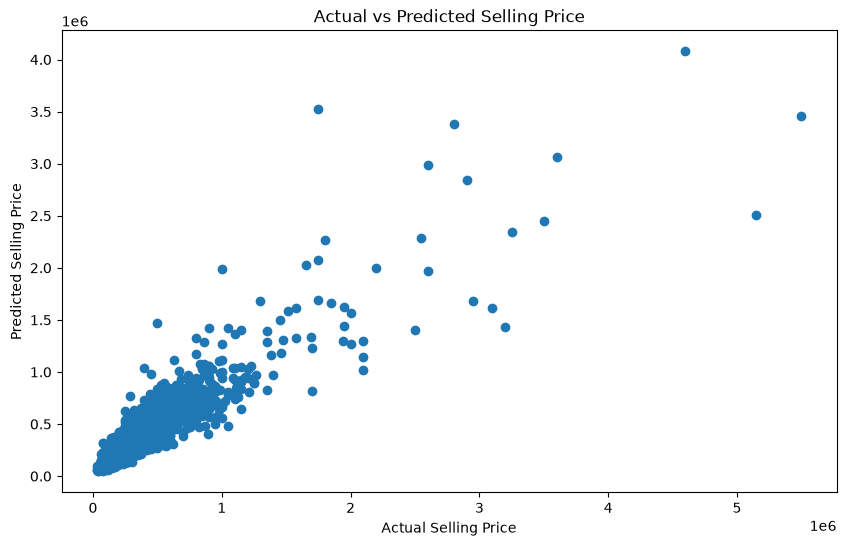

In [88]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, loaded_model.predict(x_test_pca))
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Selling Price')
plt.show()

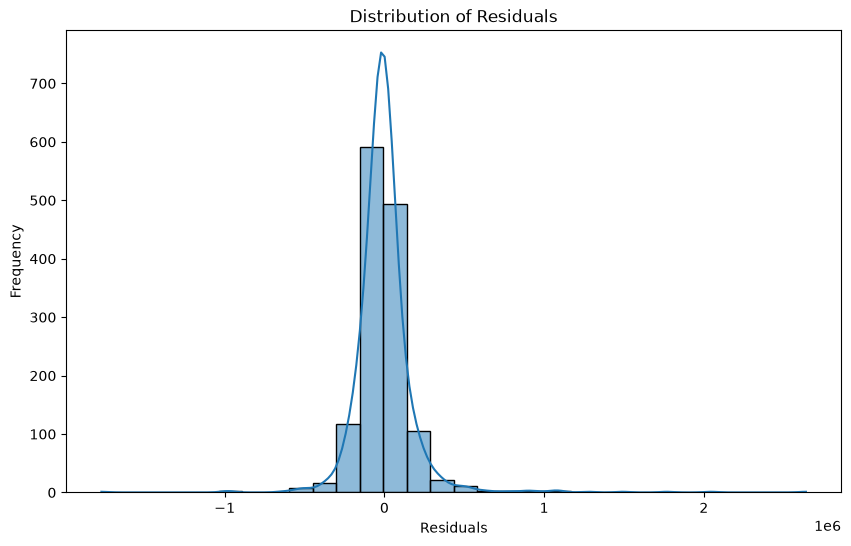

In [89]:
plt.figure(figsize=(10,6))
sns.histplot(y_test - loaded_model.predict(x_test_pca), bins=30, kde=True)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.show()

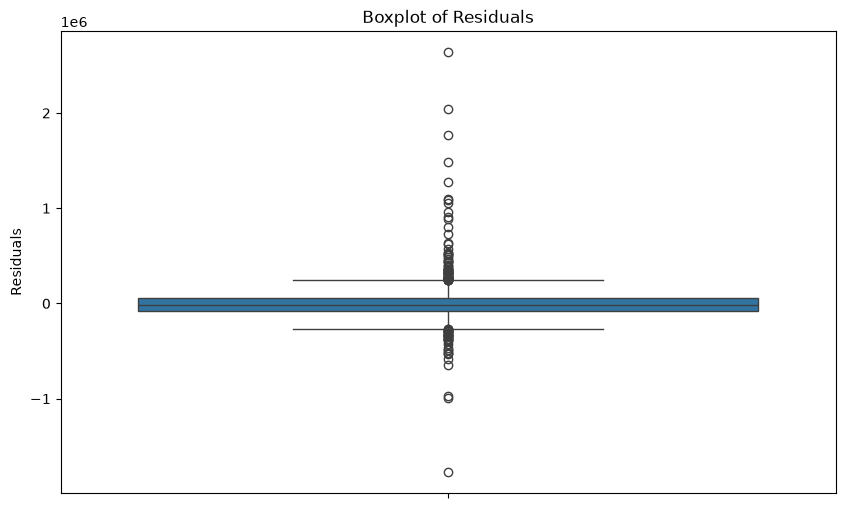

In [90]:
plt.figure(figsize=(10,6))
sns.boxplot(y_test - loaded_model.predict(x_test_pca))
plt.ylabel('Residuals')
plt.title('Boxplot of Residuals')
plt.show()

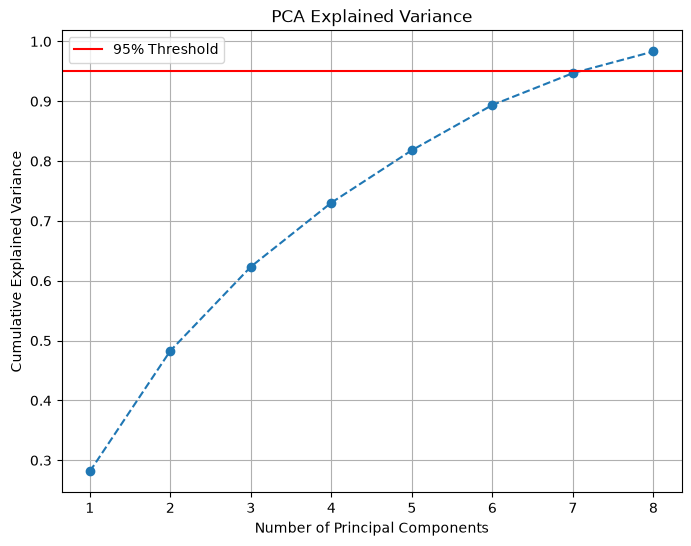

In [91]:
plt.figure(figsize=(8, 6))
# Calculate cumulative sum of explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Threshold')

plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.legend()
plt.grid(True)
plt.show()